## 📦 STEP 1 — Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import joblib
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Semua library berhasil diimport!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   sklearn : {__import__("sklearn").__version__}')

✅ Semua library berhasil diimport!
   pandas  : 2.3.3
   numpy   : 2.2.6
   sklearn : 1.7.2


## 📂 STEP 2 — Upload & Baca File Excel Motor

In [26]:
file_name = "data_motor_real.xlsx"
print(f"File digunakan: {file_name}")

File digunakan: data_motor_real.xlsx


In [27]:
# Baca sheet OTR — header di baris ke-2 (index 1) karena baris pertama adalah info kota
df_raw = pd.read_excel(file_name, sheet_name='OTR', header=1)

print(f'Shape raw data: {df_raw.shape}')
print(f'\nKolom yang tersedia:')
print(df_raw.columns.tolist())
print(f'\nPreview 5 baris pertama:')
df_raw.head()

Shape raw data: (119, 5)

Kolom yang tersedia:
['TYPE', 'Unnamed: 1', 'Jember', 'Jember.1', 'Jember.2']

Preview 5 baris pertama:


,TYPE,Unnamed: 1,Jember,Jember.1,Jember.2
0,NF11T14C01 M/T,Revo Fit,16709000.0,16709000.0,19475000.0
1,NF11T14C03 M/T,Revo X,18415000.0,18415000.0,21175000.0
2,G2A02N02S3 M/T,Supra X 125 Sp,19935000.0,19935000.0,22725000.0
3,G2A02Q02S3 M/T,Supra X 125 CW,21024000.0,21024000.0,23800000.0
4,G2E02R21M1 M/T,GTR 150 Sporty,26211000.0,26211000.0,28975000.0


## 🧹 STEP 3 & 4 — Cleaning Data & Ambil Kolom Penting

Sheet OTR memiliki kolom:
- `TYPE` = kode tipe motor
- `Unnamed: 1` = nama motor
- `Jember` (APR), `Jember.1` (MEI), `Jember.2` (NEW) = harga OTR per periode

Kita gunakan kolom **NEW** (harga terbaru) sebagai harga acuan.

In [28]:
# Ambil hanya 2 kolom penting: nama motor + harga OTR terbaru (kolom 'NEW')
df_motor = df_raw[['Unnamed: 1', 'Jember.2']].copy()
df_motor.columns = ['nama_motor', 'harga_otr']

# ── Buang baris yang kolom harga_otr berisi formula Excel (=...) ──────────────
# Hal ini terjadi karena openpyxl kadang membaca formula sebagai string
df_motor = df_motor[~df_motor['harga_otr'].astype(str).str.startswith('=')]

print('Sebelum cleaning:')
print(f'  Total baris  : {len(df_motor)}')
print(f'  Missing value: {df_motor.isnull().sum().to_dict()}')

df_motor.head(10)

Sebelum cleaning:
  Total baris  : 119
  Missing value: {'nama_motor': 0, 'harga_otr': 40}


,nama_motor,harga_otr
0,Revo Fit,19475000.0
1,Revo X,21175000.0
2,Supra X 125 Sp,22725000.0
3,Supra X 125 CW,23800000.0
4,GTR 150 Sporty,28975000.0
5,GTR 150 Exc,29225000.0
6,BeAT Sporty CW,NaN
7,BeAT Sporty CBS,NaN
8,BeAT Sporty CBS ISS,NaN
9,BeAT Street,NaN


## 🔧 STEP 5 — Menangani Missing Value

In [29]:
# Hapus baris yang nama_motor atau harga_otr kosong
df_motor.dropna(subset=['nama_motor', 'harga_otr'], inplace=True)

# Pastikan harga_otr numerik (paksa konversi, set NaN jika gagal)
df_motor['harga_otr'] = pd.to_numeric(df_motor['harga_otr'], errors='coerce')
df_motor.dropna(subset=['harga_otr'], inplace=True)

# Hapus baris jika harga = 0 atau negatif (data tidak valid)
df_motor = df_motor[df_motor['harga_otr'] > 0].copy()

# Hapus duplikat berdasarkan nama motor
df_motor.drop_duplicates(subset=['nama_motor'], inplace=True)

# Reset index
df_motor.reset_index(drop=True, inplace=True)

df_motor['harga_otr'] = df_motor['harga_otr'].astype(float)

print('Setelah cleaning:')
print(f'  Total motor valid : {len(df_motor)}')
print(f'  Missing value     : {df_motor.isnull().sum().to_dict()}')
print(f'  Harga min         : Rp {df_motor["harga_otr"].min():,.0f}')
print(f'  Harga max         : Rp {df_motor["harga_otr"].max():,.0f}')

df_motor.head(10)

Setelah cleaning:
  Total motor valid : 77
  Missing value     : {'nama_motor': 0, 'harga_otr': 0}
  Harga min         : Rp 19,475,000
  Harga max         : Rp 96,250,000


,nama_motor,harga_otr
0,Revo Fit,19475000.0
1,Revo X,21175000.0
2,Supra X 125 Sp,22725000.0
3,Supra X 125 CW,23800000.0
4,GTR 150 Sporty,28975000.0
5,GTR 150 Exc,29225000.0
6,Forza,94325000.0
7,CB 150 Verza Sp,26050000.0
8,CB 150 Verza CW,26750000.0
9,CRF150L,38675000.0


## 📋 STEP 5b — Baca Cicilan Nyata dari Sheet Motor

File Excel menyediakan simulasi cicilan nyata dari dealer:
- **Motor konvensional**: tenor 12, 18, 24, 30, 36 bulan
- **Motor listrik** (EM1 e, CUV E, ICON E, dll): TOP 11, 17, 23, 29, 35, 47, 59 bulan *(ICON E hanya s/d 47)*

Perbaikan dari versi sebelumnya:
1. **Header tenor dibaca secara dinamis** — beberapa sheet (Sonic, SuperCub) punya baris kosong ekstra sehingga tenor tidak selalu ada di baris index 1
2. **OTR dicari secara dinamis** — sheet lama/duplikat (OLD BEAT, Scoopy Korumi, dll) kadang OTR = 0 di kolom A; kode kini scan beberapa baris untuk OTR valid
3. **Tenor diambil dari data nyata sheet** — ICON E hanya punya T.O.P s/d 47, bukan 59


In [30]:
import openpyxl

# Sheet yang bukan data motor individual
SKIP_SHEETS = {'OTR', 'Sheet1', 'Sheet2', 'Sheet3'}

# Daftar sheet motor listrik (TOP berbeda)
ELECTRIC_SHEETS = {
    'EM1 e (Gratis Charger)', 'Em1 e  Plus (Gratis Charger)',
    'ICON E', 'CUV E', 'CUV E CHARGER',
    'CUV E ROADSYNC DUO', 'CUV E ROADSYNC DUO CHARGER',
    'EM1 e + CHARGER', 'EM1 e PLUS + Charge'
}

# Tenor valid per jenis motor
TENOR_KONV  = {12, 18, 24, 30, 36}
TENOR_ELEC  = {11, 17, 23, 29, 35, 47, 59}

wb = openpyxl.load_workbook(file_name, read_only=True, data_only=True)

cicilan_dict = {}   # {sheet_name: {'otr': float, 'tenors': [...], 'rows': [{dp, cicilans}]}}
skipped_log  = []   # sheet yang dilewati beserta alasannya

for sname in wb.sheetnames:
    if sname in SKIP_SHEETS:
        continue

    ws = wb[sname]
    all_rows = list(ws.iter_rows(max_row=60, values_only=True))

    if len(all_rows) < 3:
        skipped_log.append((sname, 'kurang dari 3 baris'))
        continue

    is_electric  = sname in ELECTRIC_SHEETS
    tenor_valid  = TENOR_ELEC if is_electric else TENOR_KONV

    # ── FIX 1: Scan dinamis untuk baris header tenor ──────────────────────
    # Beberapa sheet (Sonic, SuperCub) punya baris kosong ekstra di atas
    # sehingga header tenor tidak selalu ada di index [1].
    header_row   = None
    tenor_cols   = []
    data_start   = 2   # default

    for row_idx in range(min(4, len(all_rows))):
        row = all_rows[row_idx]
        found = [(i, v) for i, v in enumerate(row)
                 if isinstance(v, (int, float)) and int(v) in tenor_valid]
        if found:
            header_row  = row
            tenor_cols  = found
            data_start  = row_idx + 1
            break

    if not tenor_cols:
        skipped_log.append((sname, 'tidak ada kolom tenor valid ditemukan'))
        continue

    # ── FIX 2: Cari OTR secara dinamis, scan mulai dari data_start ───────
    # Sheet yang OTR-nya kosong/nol di baris pertama data (OLD BEAT, dll.)
    # biasanya tidak punya harga di kolom A karena sheet lama/duplikat.
    # Scan beberapa baris untuk menemukan OTR valid (> 1_000_000).
    otr_val = None
    for r in all_rows[data_start: data_start + 5]:
        v = r[0] if r else None
        if isinstance(v, (int, float)) and v > 1_000_000:
            otr_val = v
            break

    if otr_val is None:
        skipped_log.append((sname, 'OTR tidak ditemukan atau tidak valid'))
        continue

    tenors     = [v for _, v in tenor_cols]
    rows_data  = []

    for r in all_rows[data_start:]:
        dp_val = r[1] if len(r) > 1 else None
        if not isinstance(dp_val, (int, float)) or dp_val <= 0:
            continue
        cicilan_row = {}
        for col_i, tenor in tenor_cols:
            val = r[col_i] if col_i < len(r) else None
            if isinstance(val, (int, float)) and val > 0:
                cicilan_row[int(tenor)] = val
        if cicilan_row:
            rows_data.append({'dp': dp_val, 'cicilans': cicilan_row})

    if rows_data:
        cicilan_dict[sname] = {
            'otr'        : otr_val,
            'tenors'     : [int(t) for t in tenors],
            'is_electric': is_electric,
            'rows'       : rows_data
        }
    else:
        skipped_log.append((sname, 'tidak ada baris data cicilan valid'))

wb.close()

print(f'✅ Berhasil membaca {len(cicilan_dict)} sheet cicilan nyata')
print(f'⚠️  Sheet dilewati  : {len(skipped_log)} sheet')

if skipped_log:
    print('\n   Rincian sheet dilewati:')
    for s, alasan in skipped_log:
        print(f'     [{s}]: {alasan}')

# Preview 3 sheet pertama
print()
for sname, d in list(cicilan_dict.items())[:3]:
    print(f'  [{sname}] OTR=Rp{d["otr"]:,.0f} | Tenor={d["tenors"]} | {len(d["rows"])} baris DP')
    print(f'    Contoh: DP=Rp{d["rows"][0]["dp"]:,.0f} → {d["rows"][0]["cicilans"]}')


✅ Berhasil membaca 66 sheet cicilan nyata
⚠️  Sheet dilewati  : 12 sheet

   Rincian sheet dilewati:
     [BEAT SPORTY CBS ]: OTR tidak ditemukan atau tidak valid
     [BEAT SPORTY CBS ISS ]: OTR tidak ditemukan atau tidak valid
     [BEAT SPORTY DX CBS ISS ]: OTR tidak ditemukan atau tidak valid
     [BEAT STREET ]: OTR tidak ditemukan atau tidak valid
     [OLD BEAT CBS]: OTR tidak ditemukan atau tidak valid
     [NEW BEAT ISS]: OTR tidak ditemukan atau tidak valid
     [OLD BEAT ISS DX]: OTR tidak ditemukan atau tidak valid
     [OLD BEAT STREET]: OTR tidak ditemukan atau tidak valid
     [NEW SCOOPY KORUMI]: OTR tidak ditemukan atau tidak valid
     [Vario 125 CBS ISS (BL)]: OTR tidak ditemukan atau tidak valid
     [CBR150R Std (HM Matte) ]: OTR tidak ditemukan atau tidak valid
     [CBR150R Std (MP & RD)]: OTR tidak ditemukan atau tidak valid

  [ REVO X] OTR=Rp21,175,000 | Tenor=[12, 18, 24, 30, 36] | 58 baris DP
    Contoh: DP=Rp2,200,000 → {12: 2157000, 18: 1547000, 24: 125600

## ⚙️ STEP 6 — Preprocessing Data

In [31]:
def kategorikan_motor(harga):
    """Kategorikan motor berdasarkan harga OTR."""
    if harga < 25_000_000:
        return 'entry'
    elif harga < 35_000_000:
        return 'mid'
    elif harga < 50_000_000:
        return 'premium'
    else:
        return 'luxury'

df_motor['kategori_motor'] = df_motor['harga_otr'].apply(kategorikan_motor)

# Tandai motor listrik
electric_keywords = ['EM1', 'CUV', 'ICON E']
df_motor['is_electric'] = df_motor['nama_motor'].apply(
    lambda x: any(k.lower() in str(x).lower() for k in electric_keywords)
)

print('Distribusi kategori motor:')
print(df_motor['kategori_motor'].value_counts())
print()
print(f'Motor listrik : {df_motor["is_electric"].sum()} unit')
print(f'Motor konvensional: {(~df_motor["is_electric"]).sum()} unit')
df_motor.head()

Distribusi kategori motor:
kategori_motor
premium    27
mid        20
luxury     17
entry      13
Name: count, dtype: int64

Motor listrik : 13 unit
Motor konvensional: 64 unit


,nama_motor,harga_otr,kategori_motor,is_electric
0,Revo Fit,19475000.0,entry,False
1,Revo X,21175000.0,entry,False
2,Supra X 125 Sp,22725000.0,entry,False
3,Supra X 125 CW,23800000.0,entry,False
4,GTR 150 Sporty,28975000.0,mid,False


## 🔄 STEP 7 & 8 — Generate Dataset Simulasi + Logika Tenor

**Logika penentuan tenor berdasarkan tenor yang tersedia di Excel:**

| Jenis Motor | Tenor Tersedia |
|---|---|
| Konvensional | 12, 18, 24, 30, 36 bulan |
| Listrik (EM1 e, CUV E) | TOP 11, 17, 23, 29, 35, 47, 59 bulan |
| Listrik (ICON E) | TOP 11, 17, 23, 29, 35, 47 bulan *(tanpa 59)* |

Aturan: cicilan bulanan ≤ 30% penghasilan (prinsip finansial sehat). Pilih tenor **terpendek** yang masih terjangkau.

> **Perbaikan:** `tenors_available` kini diambil langsung dari `cicilan_sheet['tenors']` sehingga otomatis menyesuaikan tenor nyata per motor (misalnya ICON E yang hanya sampai tenor 47).


In [32]:
def tentukan_tenor(harga_motor, penghasilan, dp_nominal,
                   is_electric=False, cicilan_sheet=None):
    """
    Tentukan rekomendasi tenor dari tabel cicilan nyata.

    Prioritas: cari cicilan nyata dari sheet Excel.
    Fallback  : estimasi formula flat rate jika sheet tidak tersedia.

    Parameter:
    ----------
    harga_motor   : float  — harga OTR (Rp)
    penghasilan   : float  — penghasilan bulanan bersih (Rp)
    dp_nominal    : float  — uang muka (Rp)
    is_electric   : bool   — True untuk motor listrik
    cicilan_sheet : dict | None — data cicilan dari cicilan_dict

    Return:
    -------
    tuple (tenor: int, cicilan: float, sumber: str)
    """
    batas = penghasilan * 0.30   # 30% penghasilan

    # ── FIX 3: Gunakan tenor dari sheet nyata jika tersedia ───────────────
    # ICON E hanya punya s/d tenor 47 (tidak ada 59), sehingga
    # tidak boleh hardcode. Ambil dari data sheet jika ada.
    if cicilan_sheet is not None and cicilan_sheet.get('tenors'):
        tenors_available = sorted(cicilan_sheet['tenors'])
    elif is_electric:
        tenors_available = [11, 17, 23, 29, 35, 47, 59]
    else:
        tenors_available = [12, 18, 24, 30, 36]

    # ── Coba gunakan tabel cicilan nyata ─────────────────────────────────
    if cicilan_sheet is not None and cicilan_sheet['rows']:
        # Cari baris DP terdekat
        rows = cicilan_sheet['rows']
        closest_row = min(rows, key=lambda r: abs(r['dp'] - dp_nominal))
        cicilans_nyata = closest_row['cicilans']   # {tenor: cicilan}

        for t in tenors_available:
            c = cicilans_nyata.get(t)
            if c and c <= batas:
                return t, c, 'nyata'

        # Semua tenor melampaui batas → pilih tenor terpanjang (cicilan paling ringan)
        last_t = tenors_available[-1]
        c = cicilans_nyata.get(last_t, 0)
        return last_t, c, 'nyata_paksa'

    # ── Fallback: estimasi flat rate ─────────────────────────────────────
    pokok = harga_motor - dp_nominal
    bunga = 0.011  # ~1.1% flat/bulan

    for t in tenors_available:
        cicilan = (pokok + pokok * bunga * t) / t
        if cicilan <= batas:
            return t, round(cicilan), 'estimasi'

    last_t = tenors_available[-1]
    cicilan = (pokok + pokok * bunga * last_t) / last_t
    return last_t, round(cicilan), 'estimasi_paksa'


# ── Uji logika ────────────────────────────────────────────────────────────────
print('=== Uji Logika Tenor (Konvensional) ===')
for nama, harga, gaji, dp in [
    ('BeAT CBS (~21jt)',   21_250_000, 8_000_000, 2_000_000),
    ('Vario 160 (~29jt)',  29_500_000, 5_000_000, 3_000_000),
    ('PCX 160 (~36jt)',    36_000_000, 4_000_000, 4_000_000),
    ('CBR 150R (~40jt)',   40_425_000, 3_500_000, 4_000_000),
]:
    t, c, src = tentukan_tenor(harga, gaji, dp, is_electric=False)
    print(f'  {nama:30s} | Gaji Rp{gaji:,.0f} | → Tenor {t} bln | Cicilan Rp{c:,.0f} [{src}]')

print()
print('=== Uji Logika Tenor (Motor Listrik) ===')
for nama, harga, gaji, dp in [
    ('EM1 e (~40jt)',   40_450_000, 5_000_000, 4_100_000),
    ('CUV E (~55jt)',   55_100_000, 8_000_000, 14_000_000),
    ('ICON E (~28jt)',  28_450_000, 4_000_000, 3_000_000),
]:
    t, c, src = tentukan_tenor(harga, gaji, dp, is_electric=True)
    print(f'  {nama:30s} | Gaji Rp{gaji:,.0f} | → Tenor {t} bln | Cicilan Rp{c:,.0f} [{src}]')


=== Uji Logika Tenor (Konvensional) ===
  BeAT CBS (~21jt)               | Gaji Rp8,000,000 | → Tenor 12 bln | Cicilan Rp1,815,917 [estimasi]
  Vario 160 (~29jt)              | Gaji Rp5,000,000 | → Tenor 24 bln | Cicilan Rp1,395,667 [estimasi]
  PCX 160 (~36jt)                | Gaji Rp4,000,000 | → Tenor 36 bln | Cicilan Rp1,240,889 [estimasi_paksa]
  CBR 150R (~40jt)               | Gaji Rp3,500,000 | → Tenor 36 bln | Cicilan Rp1,412,481 [estimasi_paksa]

=== Uji Logika Tenor (Motor Listrik) ===
  EM1 e (~40jt)                  | Gaji Rp5,000,000 | → Tenor 35 bln | Cicilan Rp1,438,421 [estimasi]
  CUV E (~55jt)                  | Gaji Rp8,000,000 | → Tenor 23 bln | Cicilan Rp2,239,057 [estimasi]
  ICON E (~28jt)                 | Gaji Rp4,000,000 | → Tenor 29 bln | Cicilan Rp1,157,536 [estimasi]


## 🔗 STEP 8b — Mapping Motor ke Sheet Cicilan

In [33]:
# Buat mapping dari nama_motor (OTR sheet) ke sheet cicilan
# Caranya: cocokkan nama motor dengan nama sheet (fuzzy / partial match)

def cari_sheet_cicilan(nama_motor, cicilan_dict):
    """
    Cari sheet cicilan yang paling cocok untuk suatu nama motor.
    Return: key cicilan_dict atau None
    """
    nama_lower = str(nama_motor).strip().lower()

    # Exact match dulu (case-insensitive, strip whitespace)
    for key in cicilan_dict:
        if key.strip().lower() == nama_lower:
            return key

    # Partial match: nama motor ada di key sheet atau sebaliknya
    for key in cicilan_dict:
        key_lower = key.strip().lower()
        if nama_lower in key_lower or key_lower in nama_lower:
            return key

    # Partial match token (setiap kata nama motor ada di key)
    tokens = [w for w in nama_lower.split() if len(w) > 2]
    best_key, best_score = None, 0
    for key in cicilan_dict:
        key_lower = key.strip().lower()
        score = sum(1 for t in tokens if t in key_lower)
        if score > best_score:
            best_score = score
            best_key = key

    return best_key if best_score >= max(1, len(tokens) // 2) else None


# Test mapping
print('=== Test Mapping Motor → Sheet ===')
for nama in df_motor['nama_motor'].head(10):
    key = cari_sheet_cicilan(nama, cicilan_dict)
    print(f'  {str(nama):35s} → {key}')

=== Test Mapping Motor → Sheet ===
  Revo Fit                            →  REVO FIT FI  
  Revo X                              →  REVO X
  Supra X 125 Sp                      →  SUPRA X FI SP  
  Supra X 125 CW                      →  SUPRA X FI SP  
  GTR 150 Sporty                      →  SUPRA GTR SPORTY  
  GTR 150 Exc                         →  SUPRA GTR EXCLUSIVE  
  Forza                               → None
  CB 150 Verza Sp                     →  CB 150 Verza Sp  
  CB 150 Verza CW                     →  CB 150 Verza CW  
  CRF150L                             → None


## 📊 STEP 9 — Membuat Dataset Final (Simulasi Training)

In [34]:
np.random.seed(42)

rows = []
N_SIMULASI = 200   # Simulasi per motor

for _, motor_row in df_motor.iterrows():
    harga       = motor_row['harga_otr']
    nama        = motor_row['nama_motor']
    kat         = motor_row['kategori_motor']
    is_electric = motor_row['is_electric']

    # Cari sheet cicilan nyata
    sheet_key    = cari_sheet_cicilan(nama, cicilan_dict)
    sheet_data   = cicilan_dict.get(sheet_key) if sheet_key else None

    # Rentang tenor yang berlaku
    if is_electric:
        tenors_valid = [11, 17, 23, 29, 35, 47, 59]
    else:
        tenors_valid = [12, 18, 24, 30, 36]

    # Rentang penghasilan realistis
    gaji_min = harga * 0.06
    gaji_max = harga * 1.20

    penghasilans = np.random.uniform(gaji_min, gaji_max, N_SIMULASI)

    for gaji in penghasilans:
        gaji = round(gaji / 100_000) * 100_000
        gaji = max(gaji, 1_000_000)

        dp_persen   = np.random.uniform(0.10, 0.30)
        dp_nominal  = round(harga * dp_persen / 100_000) * 100_000
        dp_nominal  = max(dp_nominal, 1_000_000)

        tenor, cicilan, sumber = tentukan_tenor(
            harga, gaji, dp_nominal,
            is_electric=is_electric,
            cicilan_sheet=sheet_data
        )

        rasio = harga / gaji

        rows.append({
            'nama_motor'      : nama,
            'harga_otr'       : harga,
            'kategori_motor'  : kat,
            'is_electric'     : int(is_electric),
            'penghasilan'     : gaji,
            'dp_persen'       : round(dp_persen, 4),
            'dp_nominal'      : dp_nominal,
            'rasio_harga_gaji': round(rasio, 4),
            'estimasi_cicilan': round(cicilan),
            'tenor'           : tenor,   # TARGET
            'sumber_cicilan'  : sumber
        })

df = pd.DataFrame(rows)
print(f'✅ Dataset berhasil dibuat!')
print(f'   Total sampel     : {len(df):,}')
print(f'   Jumlah motor     : {df["nama_motor"].nunique()}')
print()
print('   Distribusi tenor (konvensional):')
print(df[~df['is_electric'].astype(bool)]['tenor'].value_counts().sort_index())
print()
print('   Distribusi tenor (motor listrik):')
print(df[df['is_electric'].astype(bool)]['tenor'].value_counts().sort_index())
print()
print('   Sumber cicilan:')
print(df['sumber_cicilan'].value_counts())
df.head()

✅ Dataset berhasil dibuat!
   Total sampel     : 15,400
   Jumlah motor     : 77

   Distribusi tenor (konvensional):
tenor
12    10399
18      854
24      429
30      283
36      835
Name: count, dtype: int64

   Distribusi tenor (motor listrik):
tenor
11    2024
17     192
23      99
29      62
35      55
47      68
59     100
Name: count, dtype: int64

   Sumber cicilan:
sumber_cicilan
nyata             13128
estimasi           1539
nyata_paksa         672
estimasi_paksa       61
Name: count, dtype: int64


,nama_motor,harga_otr,kategori_motor,is_electric,penghasilan,dp_persen,dp_nominal,rasio_harga_gaji,estimasi_cicilan,tenor,sumber_cicilan
0,Revo Fit,19475000.0,entry,0,9500000,0.2284,4400000,2.0500,1745000,12,nyata
1,Revo Fit,19475000.0,entry,0,22300000,0.1168,2300000,0.8733,1955000,12,nyata
2,Revo Fit,19475000.0,entry,0,17400000,0.1323,2600000,1.1193,1925000,12,nyata
3,Revo Fit,19475000.0,entry,0,14500000,0.2797,5400000,1.3431,1645000,12,nyata
4,Revo Fit,19475000.0,entry,0,4600000,0.2213,4300000,4.2337,1265000,18,nyata


## 📈 STEP 10 & 11 — Exploratory Data Analysis (EDA) & Visualisasi

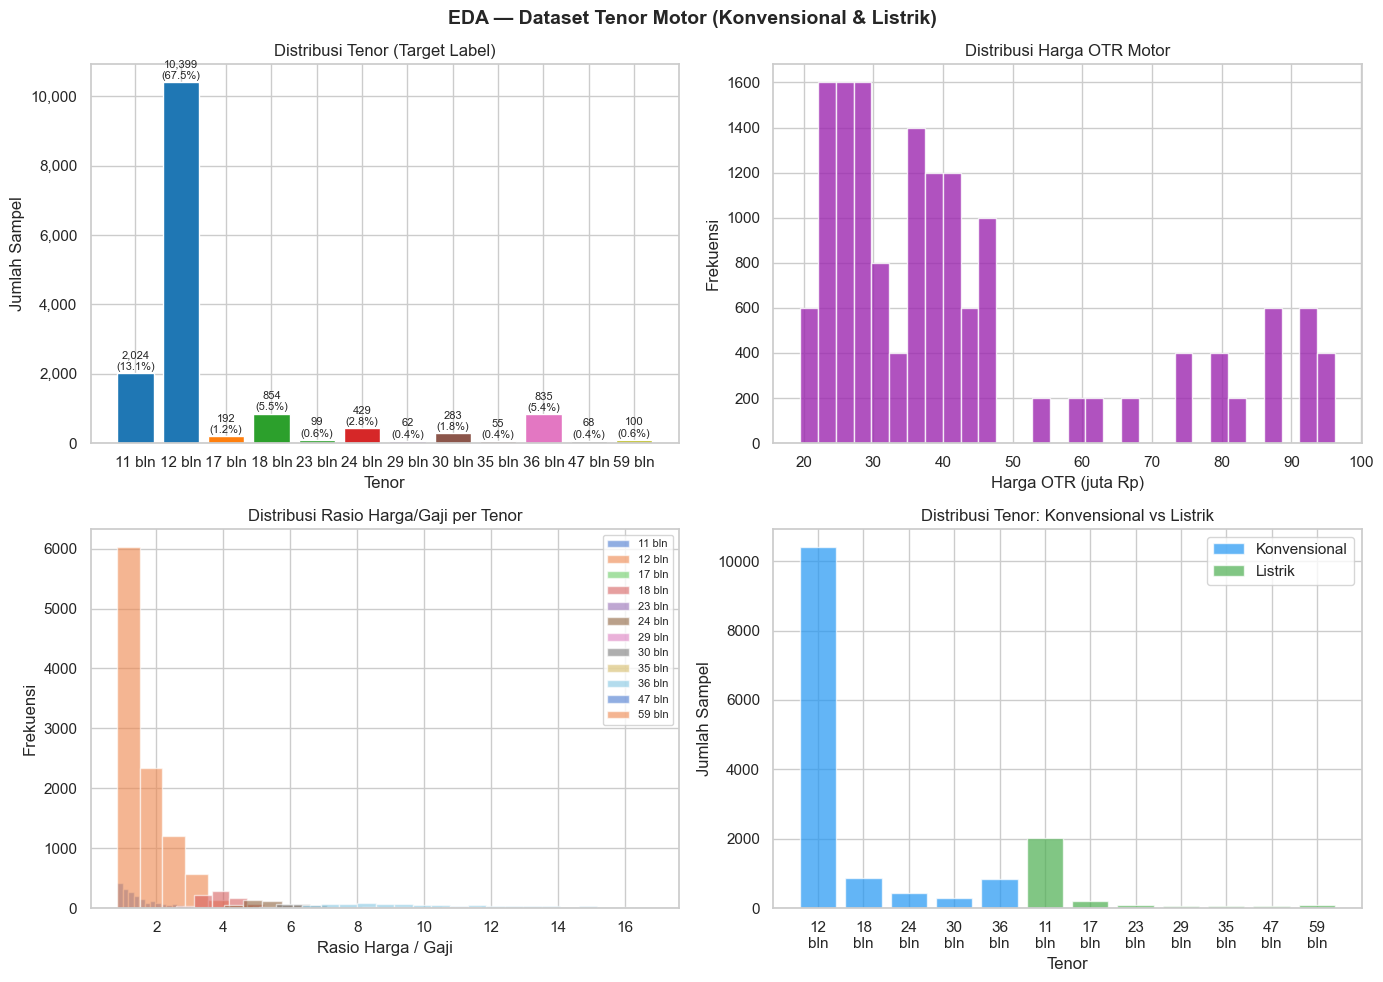

✅ Visualisasi selesai


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Dataset Tenor Motor (Konvensional & Listrik)', fontsize=14, fontweight='bold')

# ── Plot 1: Distribusi Tenor ─────────────────────────────────────────────────
ax1 = axes[0, 0]
counts = df['tenor'].value_counts().sort_index()
colors = plt.cm.tab10(np.linspace(0, 0.8, len(counts)))
bars = ax1.bar(counts.index.astype(str) + ' bln', counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8)
ax1.set_title('Distribusi Tenor (Target Label)')
ax1.set_xlabel('Tenor')
ax1.set_ylabel('Jumlah Sampel')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Plot 2: Distribusi Harga Motor ──────────────────────────────────────────
ax2 = axes[0, 1]
ax2.hist(df['harga_otr'] / 1e6, bins=30, color='#9C27B0', edgecolor='white', alpha=0.8)
ax2.set_title('Distribusi Harga OTR Motor')
ax2.set_xlabel('Harga OTR (juta Rp)')
ax2.set_ylabel('Frekuensi')

# ── Plot 3: Rasio Harga/Gaji vs Tenor ───────────────────────────────────────
ax3 = axes[1, 0]
for tenor_val in sorted(df['tenor'].unique()):
    subset = df[df['tenor'] == tenor_val]['rasio_harga_gaji']
    ax3.hist(subset, bins=20, alpha=0.6, label=f'{tenor_val} bln')
ax3.set_title('Distribusi Rasio Harga/Gaji per Tenor')
ax3.set_xlabel('Rasio Harga / Gaji')
ax3.set_ylabel('Frekuensi')
ax3.legend(fontsize=8)

# ── Plot 4: Konvensional vs Listrik ─────────────────────────────────────────
ax4 = axes[1, 1]
for jenis, label, col in [(0, 'Konvensional', '#2196F3'), (1, 'Listrik', '#4CAF50')]:
    subset = df[df['is_electric'] == jenis]['tenor'].value_counts().sort_index()
    ax4.bar([f'{t}\nbln' for t in subset.index], subset.values,
            label=label, alpha=0.7, color=col, edgecolor='white')
ax4.set_title('Distribusi Tenor: Konvensional vs Listrik')
ax4.set_xlabel('Tenor')
ax4.set_ylabel('Jumlah Sampel')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_tenor_motor.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualisasi selesai')

## 🤖 STEP 12 & 13 — Persiapan Fitur & Training Model

In [36]:
# Label encode kategori motor
le = LabelEncoder()
df['kategori_motor_enc'] = le.fit_transform(df['kategori_motor'])

# Fitur model
FEATURES = [
    'harga_otr', 'penghasilan', 'dp_persen', 'dp_nominal',
    'rasio_harga_gaji', 'estimasi_cicilan',
    'kategori_motor_enc', 'is_electric'
]
TARGET = 'tenor'

X = df[FEATURES]
y = df[TARGET]

print(f'Fitur : {FEATURES}')
print(f'Target: {TARGET}')
print(f'Shape X: {X.shape}')
print(f'Kelas target: {sorted(y.unique())}')

Fitur : ['harga_otr', 'penghasilan', 'dp_persen', 'dp_nominal', 'rasio_harga_gaji', 'estimasi_cicilan', 'kategori_motor_enc', 'is_electric']
Target: tenor
Shape X: (15400, 8)
Kelas target: [np.int64(11), np.int64(12), np.int64(17), np.int64(18), np.int64(23), np.int64(24), np.int64(29), np.int64(30), np.int64(35), np.int64(36), np.int64(47), np.int64(59)]


In [37]:
# Split train/test 80:20, stratified per tenor
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,} sampel')
print(f'Test  : {len(X_test):,} sampel')

Train : 12,320 sampel
Test  : 3,080 sampel


In [38]:
# Training RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('✅ Model selesai ditraining!')
print(f'   Pohon : {rf_model.n_estimators}')
print(f'   Kelas : {rf_model.classes_}')

✅ Model selesai ditraining!
   Pohon : 200
   Kelas : [11 12 17 18 23 24 29 30 35 36 47 59]


In [39]:
# Evaluasi model
y_pred = rf_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'\n=== EVALUASI MODEL ===')
print(f'Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))


=== EVALUASI MODEL ===
Accuracy  : 0.9808 (98.08%)

Classification Report:
              precision    recall  f1-score   support

          11       1.00      1.00      1.00       405
          12       1.00      0.99      1.00      2080
          17       1.00      0.97      0.99        38
          18       0.90      0.93      0.92       171
          23       0.95      0.95      0.95        20
          24       0.84      0.86      0.85        86
          29       0.85      0.92      0.88        12
          30       0.78      0.84      0.81        56
          35       1.00      0.82      0.90        11
          36       0.94      0.97      0.96       167
          47       0.93      1.00      0.97        14
          59       1.00      1.00      1.00        20

    accuracy                           0.98      3080
   macro avg       0.93      0.94      0.93      3080
weighted avg       0.98      0.98      0.98      3080



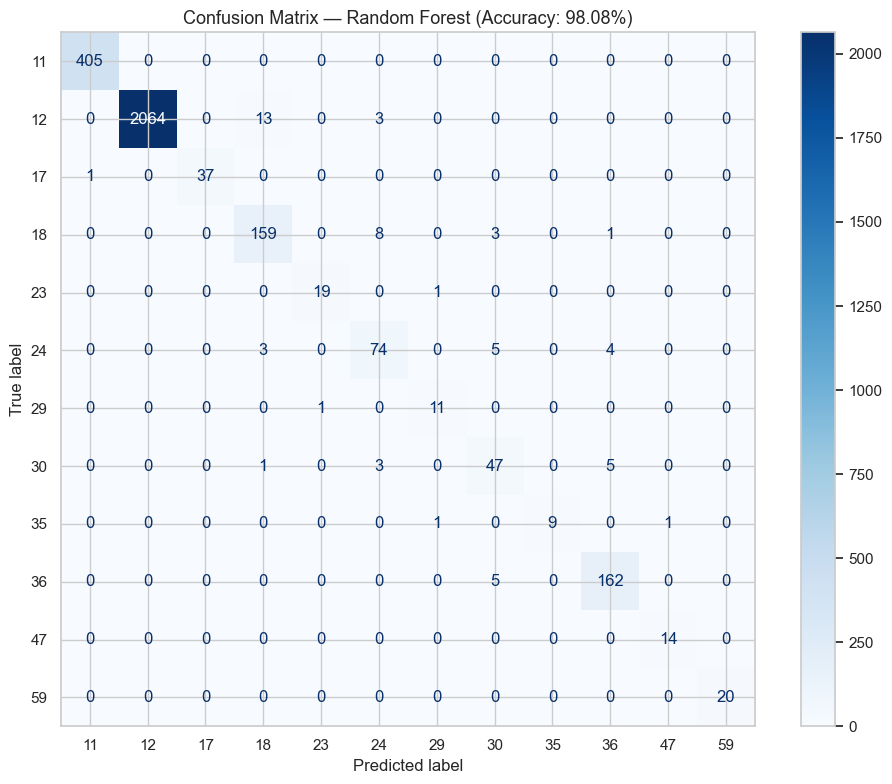

In [40]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm  = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — Random Forest (Accuracy: {acc*100:.2f}%)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

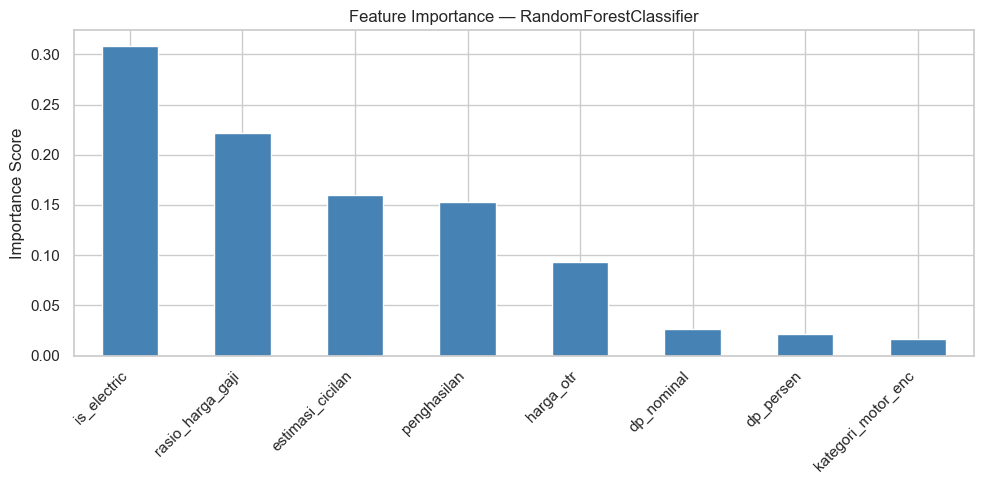

In [41]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Feature Importance — RandomForestClassifier')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔮 STEP 20 — Fungsi Prediksi Tenor Motor

In [49]:
def prediksi_tenor_motor(nama_motor, penghasilan_bulanan, dp_persen=0.15):
    """
    Prediksi tenor cicilan motor menggunakan model Random Forest.
    Menggunakan cicilan nyata dari sheet Excel jika tersedia.

    Parameter:
    ----------
    nama_motor         : str   — nama motor (harus ada di daftar)
    penghasilan_bulanan: float — penghasilan bersih per bulan (Rp)
    dp_persen          : float — persentase DP (default 15%)

    Return: dict hasil rekomendasi
    """
    motor_row = df_motor[
        df_motor['nama_motor'].str.lower() == nama_motor.strip().lower()
    ]
    if motor_row.empty:
        # Fuzzy search
        matches = df_motor[
            df_motor['nama_motor'].str.lower().str.contains(nama_motor.strip().lower(), na=False)
        ]
        if not matches.empty:
            motor_row = matches.iloc[[0]]
            print(f'  ℹ️  Motor tidak ditemukan persis. Menggunakan: "{motor_row.iloc[0]["nama_motor"]}"')
        else:
            print(f'  ❌ Motor "{nama_motor}" tidak ditemukan.')
            print(f'  💡 Daftar motor tersedia:')
            for n in sorted(df_motor['nama_motor'].tolist()):
                print(f'      - {n}')
            return None

    harga       = float(motor_row['harga_otr'].values[0])
    kategori    = motor_row['kategori_motor'].values[0]
    is_electric = bool(motor_row['is_electric'].values[0])
    kat_enc     = le.transform([kategori])[0]

    dp_nominal = round(harga * dp_persen / 100_000) * 100_000
    dp_nominal = max(dp_nominal, 1_000_000)
    rasio      = harga / penghasilan_bulanan

    # Cari cicilan nyata
    sheet_key  = cari_sheet_cicilan(motor_row.iloc[0]['nama_motor'], cicilan_dict)
    sheet_data = cicilan_dict.get(sheet_key) if sheet_key else None

    # Estimasi cicilan (untuk fitur model)
    pokok = harga - dp_nominal
    est_cicilan = (pokok + pokok * 0.011 * 24) / 24

    X_input = pd.DataFrame([{
        'harga_otr'          : harga,
        'penghasilan'        : penghasilan_bulanan,
        'dp_persen'          : dp_persen,
        'dp_nominal'         : dp_nominal,
        'rasio_harga_gaji'   : rasio,
        'estimasi_cicilan'   : est_cicilan,
        'kategori_motor_enc' : kat_enc,
        'is_electric'        : int(is_electric)
    }])

    tenor_pred = rf_model.predict(X_input)[0]
    proba      = rf_model.predict_proba(X_input)[0]
    kelas      = rf_model.classes_

    # Cari cicilan nyata untuk tenor yang direkomendasikan
    cicilan_nyata = None
    if sheet_data and sheet_data['rows']:
        closest_row = min(sheet_data['rows'], key=lambda r: abs(r['dp'] - dp_nominal))
        cicilan_nyata = closest_row['cicilans'].get(tenor_pred)

    # Fallback estimasi cicilan
    if not cicilan_nyata:
        cicilan_nyata = round((pokok + pokok * 0.011 * tenor_pred) / tenor_pred)

    pct_gaji = cicilan_nyata / penghasilan_bulanan * 100

    return {
        'nama_motor'       : motor_row.iloc[0]['nama_motor'],
        'harga_otr'        : harga,
        'penghasilan'      : penghasilan_bulanan,
        'dp_persen'        : dp_persen,
        'dp_nominal'       : dp_nominal,
        'kategori_motor'   : kategori,
        'is_electric'      : is_electric,
        'rasio_harga_gaji' : round(rasio, 2),
        'tenor_rekomendasi': tenor_pred,
        'cicilan_nyata'    : round(cicilan_nyata),
        'persen_gaji'      : round(pct_gaji, 1),
        'sheet_cicilan'    : sheet_key,
        'probabilitas'     : dict(zip(kelas, [round(p*100, 1) for p in proba]))
    }


def tampilkan_hasil(hasil):
    if hasil is None:
        return
    label_tenor = 'T.O.P' if hasil['is_electric'] else 'Tenor'
    print('\n' + '═' * 60)
    print('          HASIL REKOMENDASI TENOR CICILAN')
    print('═' * 60)
    print(f'  Motor          : {hasil["nama_motor"]}')
    print(f'  Jenis          : {"⚡ Listrik" if hasil["is_electric"] else "🏍️  Konvensional"}')
    print(f'  Harga OTR      : Rp {hasil["harga_otr"]:>15,.0f}')
    print(f'  Penghasilan    : Rp {hasil["penghasilan"]:>15,.0f}')
    print(f'  Uang Muka      : Rp {hasil["dp_nominal"]:>15,.0f} ({hasil["dp_persen"]*100:.0f}%)')
    print(f'  Rasio H/G      : {hasil["rasio_harga_gaji"]}×')
    if hasil['sheet_cicilan']:
        print(f'  Sumber Cicilan : {hasil["sheet_cicilan"]}')
    print('─' * 60)
    print(f'  ✅ {label_tenor} REKOMENDASI : {hasil["tenor_rekomendasi"]} BULAN')
    print(f'  💰 Cicilan/bln          : Rp {hasil["cicilan_nyata"]:>12,.0f}')
    print(f'  📊 % dari Penghasilan   : {hasil["persen_gaji"]}%')
    print('─' * 60)
    print('  Probabilitas per Tenor:')
    for t_val, prob in sorted(hasil['probabilitas'].items()):
        bar = '█' * int(prob / 5)
        marker = ' ◄' if t_val == hasil['tenor_rekomendasi'] else ''
        print(f'    {t_val:3d} bln: {bar:<20} {prob}%{marker}')
    print('═' * 60)

In [50]:
# ── Contoh Prediksi Konvensional ─────────────────────────────────────────────
print('=== CONTOH PREDIKSI 1 — Motor Konvensional ===')
hasil1 = prediksi_tenor_motor('New BeAT Sporty CBS', penghasilan_bulanan=3_500_000)
tampilkan_hasil(hasil1)

print('\n=== CONTOH PREDIKSI 2 — Motor Konvensional ===')
hasil2 = prediksi_tenor_motor('PCX CBS 160', penghasilan_bulanan=5_000_000, dp_persen=0.20)
tampilkan_hasil(hasil2)

print('\n=== CONTOH PREDIKSI 3 — Motor Konvensional ===')
hasil3 = prediksi_tenor_motor('Vario160 CBS', penghasilan_bulanan=7_000_000, dp_persen=0.25)
tampilkan_hasil(hasil3)

=== CONTOH PREDIKSI 1 — Motor Konvensional ===

════════════════════════════════════════════════════════════
          HASIL REKOMENDASI TENOR CICILAN
════════════════════════════════════════════════════════════
  Motor          : New BeAT Sporty CBS
  Jenis          : 🏍️  Konvensional
  Harga OTR      : Rp      21,250,000
  Penghasilan    : Rp       3,500,000
  Uang Muka      : Rp       3,200,000 (15%)
  Rasio H/G      : 6.07×
  Sumber Cicilan : NEW BEAT CBS
────────────────────────────────────────────────────────────
  ✅ Tenor REKOMENDASI : 30 BULAN
  💰 Cicilan/bln          : Rp    1,026,000
  📊 % dari Penghasilan   : 29.3%
────────────────────────────────────────────────────────────
  Probabilitas per Tenor:
     11 bln:                      0.0%
     12 bln:                      0.0%
     17 bln:                      0.0%
     18 bln:                      0.0%
     23 bln:                      0.0%
     24 bln:                      2.6%
     29 bln:                      0.0%
     3

In [44]:
# ── Contoh Prediksi Motor Listrik ────────────────────────────────────────────
print('=== CONTOH PREDIKSI 4 — Motor Listrik (EM1 e) ===')
hasil4 = prediksi_tenor_motor('EM1 e', penghasilan_bulanan=5_000_000, dp_persen=0.15)
tampilkan_hasil(hasil4)

print('\n=== CONTOH PREDIKSI 5 — Motor Listrik (CUV E) ===')
hasil5 = prediksi_tenor_motor('CUV E', penghasilan_bulanan=8_000_000, dp_persen=0.25)
tampilkan_hasil(hasil5)

print('\n=== CONTOH PREDIKSI 6 — Motor Listrik (ICON E) ===')
hasil6 = prediksi_tenor_motor('ICON E', penghasilan_bulanan=4_000_000, dp_persen=0.15)
tampilkan_hasil(hasil6)

=== CONTOH PREDIKSI 4 — Motor Listrik (EM1 e) ===
  ℹ️  Motor tidak ditemukan persis. Menggunakan: "EM1 e:"

════════════════════════════════════════════════════════════
          HASIL REKOMENDASI TENOR CICILAN
════════════════════════════════════════════════════════════
  Motor          : EM1 e:
  Jenis          : ⚡ Listrik
  Harga OTR      : Rp      40,450,000
  Penghasilan    : Rp       5,000,000
  Uang Muka      : Rp       6,100,000 (15%)
  Rasio H/G      : 8.09×
  Sumber Cicilan : EM1 e (Gratis Charger)
────────────────────────────────────────────────────────────
  ✅ T.O.P REKOMENDASI : 47 BULAN
  💰 Cicilan/bln          : Rp    1,418,000
  📊 % dari Penghasilan   : 28.4%
────────────────────────────────────────────────────────────
  Probabilitas per Tenor:
     11 bln:                      0.0%
     12 bln:                      0.0%
     17 bln:                      0.0%
     18 bln:                      0.0%
     23 bln:                      0.1%
     24 bln:                     

## 💾 STEP 21 — Simpan Model ke File .pkl

In [45]:
os.makedirs('model', exist_ok=True)

joblib.dump(rf_model,     'model/rf_tenor_motor.pkl')
joblib.dump(le,           'model/label_encoder.pkl')
joblib.dump(df_motor,     'model/data_motor.pkl')
joblib.dump(cicilan_dict, 'model/cicilan_dict.pkl')   # ← cicilan nyata

print('✅ Model berhasil disimpan!')
for fname in sorted(os.listdir('model')):
    fpath = os.path.join('model', fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'   {fname:35s}: {size:.1f} KB')

✅ Model berhasil disimpan!
   cicilan_dict.pkl                   : 204.5 KB
   data_motor.pkl                     : 3.7 KB
   label_encoder.pkl                  : 0.5 KB
   rf_tenor_motor.pkl                 : 19471.5 KB


## 🔁 STEP 22 — Load Model Kembali

In [46]:
loaded_model       = joblib.load('model/rf_tenor_motor.pkl')
loaded_encoder     = joblib.load('model/label_encoder.pkl')
loaded_df_motor    = joblib.load('model/data_motor.pkl')
loaded_cicilan     = joblib.load('model/cicilan_dict.pkl')

print('✅ Model berhasil di-load!')
print(f'   Tipe model    : {type(loaded_model).__name__}')
print(f'   Jumlah pohon  : {loaded_model.n_estimators}')
print(f'   Kelas target  : {loaded_model.classes_}')
print(f'   Jumlah motor  : {len(loaded_df_motor)}')
print(f'   Sheet cicilan : {len(loaded_cicilan)} sheet')

✅ Model berhasil di-load!
   Tipe model    : RandomForestClassifier
   Jumlah pohon  : 200
   Kelas target  : [11 12 17 18 23 24 29 30 35 36 47 59]
   Jumlah motor  : 77
   Sheet cicilan : 66 sheet


## 🧪 STEP 23 — Prediksi dari Input User (Interaktif)

In [51]:

def prediksi_dari_input(nama_motor_input, penghasilan_input, dp_persen_input=0.15):
    """
    Fungsi prediksi menggunakan model yang di-load dari file.
    Simulasi alur penggunaan production.
    """
    motor_row = loaded_df_motor[
        loaded_df_motor['nama_motor'].str.lower().str.contains(
            nama_motor_input.strip().lower(), na=False
        )
    ]
    if motor_row.empty:
        return {"error": f"Motor '{nama_motor_input}' tidak ditemukan."}

    motor_row = motor_row.iloc[[0]]
    harga       = float(motor_row['harga_otr'].values[0])
    kategori    = motor_row['kategori_motor'].values[0]
    is_electric = bool(motor_row['is_electric'].values[0])
    kat_enc     = loaded_encoder.transform([kategori])[0]

    dp_nominal = round(harga * dp_persen_input / 100_000) * 100_000
    dp_nominal = max(dp_nominal, 1_000_000)
    rasio      = harga / penghasilan_input
    pokok      = harga - dp_nominal

    # Cari cicilan nyata
    sheet_key  = cari_sheet_cicilan(motor_row.iloc[0]['nama_motor'], loaded_cicilan)
    sheet_data = loaded_cicilan.get(sheet_key) if sheet_key else None

    X_input = pd.DataFrame([{
        'harga_otr'          : harga,
        'penghasilan'        : penghasilan_input,
        'dp_persen'          : dp_persen_input,
        'dp_nominal'         : dp_nominal,
        'rasio_harga_gaji'   : rasio,
        'estimasi_cicilan'   : (pokok + pokok * 0.011 * 24) / 24,
        'kategori_motor_enc' : kat_enc,
        'is_electric'        : int(is_electric)
    }])

    tenor_pred = int(loaded_model.predict(X_input)[0])

    # Cicilan nyata
    cicilan = None
    if sheet_data and sheet_data['rows']:
        closest = min(sheet_data['rows'], key=lambda r: abs(r['dp'] - dp_nominal))
        cicilan = closest['cicilans'].get(tenor_pred)
    if not cicilan:
        cicilan = round((pokok + pokok * 0.011 * tenor_pred) / tenor_pred)

    return {
        "motor"             : motor_row.iloc[0]['nama_motor'],
        "harga_otr"         : int(harga),
        "penghasilan"       : int(penghasilan_input),
        "dp_nominal"        : int(dp_nominal),
        "tenor_rekomendasi" : tenor_pred,
        "cicilan_per_bulan" : int(cicilan),
        "is_electric"       : is_electric,
        "label_tenor"       : 'T.O.P' if is_electric else 'Tenor',
    }


# ── Simulasi Input User ───────────────────────────────────────────────────────
import json

hasil_json = prediksi_dari_input(
    nama_motor_input  = 'Vario160',
    penghasilan_input = 6_000_000,
    dp_persen_input   = 0.20
)
print('Output JSON (untuk API):')
print(json.dumps(hasil_json, indent=2, ensure_ascii=False))

print()
hasil_json2 = prediksi_dari_input(
    nama_motor_input  = 'CUV E',
    penghasilan_input = 7_000_000,
    dp_persen_input   = 0.25
)
print('Output JSON (motor listrik):')
print(json.dumps(hasil_json2, indent=2, ensure_ascii=False))

Output JSON (untuk API):
{
  "motor": "Vario160 CBS",
  "harga_otr": 29500000,
  "penghasilan": 6000000,
  "dp_nominal": 5900000,
  "tenor_rekomendasi": 24,
  "cicilan_per_bulan": 1079000,
  "is_electric": false,
  "label_tenor": "Tenor"
}

Output JSON (motor listrik):
{
  "motor": "CUV E:",
  "harga_otr": 55100000,
  "penghasilan": 7000000,
  "dp_nominal": 13800000,
  "tenor_rekomendasi": 35,
  "cicilan_per_bulan": 2184000,
  "is_electric": true,
  "label_tenor": "T.O.P"
}


## 🌐 STEP 24 — Integrasi Sederhana ke FastAPI

In [25]:
fastapi_code = '''
# ─────────────────────────────────────────────────────────────────────────────
# main.py — FastAPI Backend Sistem Rekomendasi Tenor Motor
# Install: pip install fastapi uvicorn joblib pandas scikit-learn openpyxl
# Run    : uvicorn main:app --reload
# ─────────────────────────────────────────────────────────────────────────────

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field, validator
from typing import Optional
import pandas as pd
import joblib
import os

app = FastAPI(
    title="Sistem Rekomendasi Tenor Motor",
    description="API rekomendasi tenor cicilan sepeda motor (konvensional & listrik)",
    version="2.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"]
)

MODEL_DIR    = "model"
model        = joblib.load(f"{MODEL_DIR}/rf_tenor_motor.pkl")
encoder      = joblib.load(f"{MODEL_DIR}/label_encoder.pkl")
df_motor     = joblib.load(f"{MODEL_DIR}/data_motor.pkl")
cicilan_dict = joblib.load(f"{MODEL_DIR}/cicilan_dict.pkl")


def cari_sheet_cicilan(nama_motor, cicilan_dict):
    nama_lower = str(nama_motor).strip().lower()
    for key in cicilan_dict:
        if key.strip().lower() == nama_lower:
            return key
    for key in cicilan_dict:
        if nama_lower in key.strip().lower() or key.strip().lower() in nama_lower:
            return key
    return None


class PrediksiRequest(BaseModel):
    nama_motor : str   = Field(..., example="Vario160 CBS")
    penghasilan: float = Field(..., ge=500_000, example=5_000_000)
    dp_persen  : float = Field(0.15, ge=0.10, le=0.50)


class PrediksiResponse(BaseModel):
    motor              : str
    harga_otr          : int
    penghasilan        : int
    dp_nominal         : int
    tenor_rekomendasi  : int
    cicilan_per_bulan  : int
    persen_dari_gaji   : float
    kategori_motor     : str
    is_electric        : bool
    label_tenor        : str


@app.get("/motors")
def daftar_motor():
    motors = df_motor[["nama_motor", "harga_otr", "kategori_motor", "is_electric"]].to_dict("records")
    return {"total": len(motors), "motors": motors}


@app.post("/predict", response_model=PrediksiResponse)
def predict_tenor(req: PrediksiRequest):
    rows = df_motor[
        df_motor["nama_motor"].str.lower().str.contains(req.nama_motor.strip().lower(), na=False)
    ]
    if rows.empty:
        raise HTTPException(status_code=404, detail=f"Motor \'{req.nama_motor}\' tidak ditemukan")

    row         = rows.iloc[0]
    harga       = float(row["harga_otr"])
    kategori    = row["kategori_motor"]
    is_electric = bool(row["is_electric"])
    kat_enc     = encoder.transform([kategori])[0]

    dp_nominal = round(harga * req.dp_persen / 100_000) * 100_000
    dp_nominal = max(dp_nominal, 1_000_000)
    rasio      = harga / req.penghasilan
    pokok      = harga - dp_nominal

    sheet_key  = cari_sheet_cicilan(row["nama_motor"], cicilan_dict)
    sheet_data = cicilan_dict.get(sheet_key) if sheet_key else None

    X_input = pd.DataFrame([{
        "harga_otr"          : harga,
        "penghasilan"        : req.penghasilan,
        "dp_persen"          : req.dp_persen,
        "dp_nominal"         : dp_nominal,
        "rasio_harga_gaji"   : rasio,
        "estimasi_cicilan"   : (pokok + pokok * 0.011 * 24) / 24,
        "kategori_motor_enc" : kat_enc,
        "is_electric"        : int(is_electric)
    }])

    tenor = int(model.predict(X_input)[0])

    cicilan = None
    if sheet_data and sheet_data["rows"]:
        closest = min(sheet_data["rows"], key=lambda r: abs(r["dp"] - dp_nominal))
        cicilan = closest["cicilans"].get(tenor)
    if not cicilan:
        cicilan = round((pokok + pokok * 0.011 * tenor) / tenor)

    pct = round(cicilan / req.penghasilan * 100, 1)
    label = "T.O.P" if is_electric else "Tenor"

    return PrediksiResponse(
        motor=row["nama_motor"],
        harga_otr=int(harga),
        penghasilan=int(req.penghasilan),
        dp_nominal=int(dp_nominal),
        tenor_rekomendasi=tenor,
        cicilan_per_bulan=int(cicilan),
        persen_dari_gaji=pct,
        kategori_motor=kategori,
        is_electric=is_electric,
        label_tenor=label
    )


@app.get("/")
def root():
    return {"message": "Sistem Rekomendasi Tenor Motor API v2.0", "docs": "/docs"}
'''

with open('main.py', 'w', encoding='utf-8') as f:
    f.write(fastapi_code)

print('✅ File main.py berhasil dibuat!')
print('\nUntuk menjalankan API:')
print('  pip install fastapi uvicorn')
print('  uvicorn main:app --reload')
print('\nSwagger UI: http://localhost:8000/docs')

✅ File main.py berhasil dibuat!

Untuk menjalankan API:
  pip install fastapi uvicorn
  uvicorn main:app --reload

Swagger UI: http://localhost:8000/docs
